# Exploration du WARC Marsactu (j1 - 2011 à 2015)

Avant de faire de l'analyse sémantique sur le corpus, je veux comprendre ce qu'il y a dans le fichier WARC qu'on a reçu de la BnF. L'idée c'est de regarder la matière brute, pour ne pas partir tête baissée sur des données que je ne connais pas.

## 0. Questions préliminaires

Avant de lire une seule ligne de code, voilà ce que je veux savoir sur ce corpus :

**Sur le fichier lui-même**
- Quelle est la taille du fichier WARC ?
- Combien de records contient-il, et de quels types ?
- Qui a fait le crawl (exploration automatique du web page par page, où un programme suit les liens et télécharge les pages pour les archiver), avec quel outil, et sur quelle période déclarée ?

**Sur la temporalité**
- La période réelle des captures correspond-elle à la période annoncée dans le warcinfo ?
- La distribution des captures est-elle régulière ou y a-t-il des anomalies ?

**Sur les doublons**
- Y a-t-il des URLs dupliquées ? De quels types ?
- Ces doublons apportent-ils du contenu supplémentaire, ou sont-ils des copies à éliminer ?

**Sur les formats**
- Quels types de fichiers sont présents dans le corpus (HTML, images, CSS, JS, PDF…) ?
- Quelle proportion représente le contenu éditorial textuel ?

**Sur les URL de type article**
- Y a-t-il deux formats d'URL coexistants pour les articles (sans extension vs `.html`) ?
- Ces deux formats pointent-ils vers le même contenu ? Est-ce qu'on peut retrouver la version `.html` d'une URL sans extension ?

**Sur la qualité**
- Quelle proportion de records a bien été servie par le serveur (statut 200) ?
- Que représentent les redirections 301 et 302 ?

**Décision finale**
- Combien de records restent après tous les filtres, prêts pour le TAL ?

In [78]:
from warcio.archiveiterator import ArchiveIterator
from pathlib import Path
from collections import Counter
import re
import matplotlib.pyplot as plt
from datetime import datetime

# Patterns réutilisés dans tout le notebook
PATTERN_FEED = r'/feed/$'
PATTERN_REPLYTOCOM = r'replytocom=[0-9]+'
PATTERN_EXTENSION = r'\.([a-z0-9]{2,8})(?:\?|#|$)'

In [79]:
WARC_PATH = Path("../data/raw/bnf-marsactu-2011-2015.pfvd.ux.bnf.fr.warc.gz")

if WARC_PATH.exists():
    print("Fichier trouvé")
    taille_mo = WARC_PATH.stat().st_size / (1024 ** 2)
    print(f"Taille : {taille_mo:.1f} Mo")
else:
    print("Fichier non trouvé")

Fichier trouvé
Taille : 419.5 Mo


---
## 1. Structure du WARC

On commence par compter les records et lire l'en-tête `warcinfo` pour savoir qui a produit ce fichier.

In [80]:
nb_records = 0
record_types_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        nb_records += 1
        record_types_counter[record.rec_type] += 1

print(f"Nombre total de records : {nb_records}")
for rtype, count in record_types_counter.most_common():
    print(f"  {rtype} : {count}")

Nombre total de records : 23470
  response : 23469
  warcinfo : 1


In [81]:
with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            contenu = record.content_stream().read().decode("utf-8")
            print(contenu)
            break

hostname: delaware.pfvd.ux.bnf.fr
software: website-recover/3.0.0PFC30
ip: 172.20.90.124
format: WARC File Format 1.0
publisher: Bibliotheque nationale de France
description: Ce corpus correspond aux premières archives du site marsactu.fr constituées par la Bibliothèque nationale de France entre le 1er janvier 2011et le 31 décembre 2015.
conformsTo: http://bibnum.bnf.fr/WARC/WARC_ISO_28500_version1_latestdraft.pdf
operator: BnF - DLWeb



### Ce qu'on apprend du warcinfo

Le crawler utilisé est `website-recover/3.0.0PFC30`, un outil propriétaire de la BnF. Un crawler  est un programme automatique qui parcourt le web en suivant les liens d'une page à l'autre et télécharge le contenu de chaque page qu'il visite. On n'a pas accès au code de cet outil donc on ne peut pas voir exactement comment il a parcouru le site.

La description annonce la période du 1er janvier 2011 au 31 décembre 2015, mais on va voir ci-dessous que la première capture réelle date de septembre 2011. Il y a donc un écart entre la doc officielle et la réalité du fichier.

L'opérateur est BnF - DLWeb.

---
## 2. Distribution temporelle des captures

Chaque record contient une date de capture dans l'en-tête `WARC-Date`. On trace la distribution pour voir si le crawl est régulier ou non sur 2011–2015.

Records avec date : 23469
Première capture  : 2011-09-16 18:19:10
Dernière capture  : 2015-12-30 14:26:27


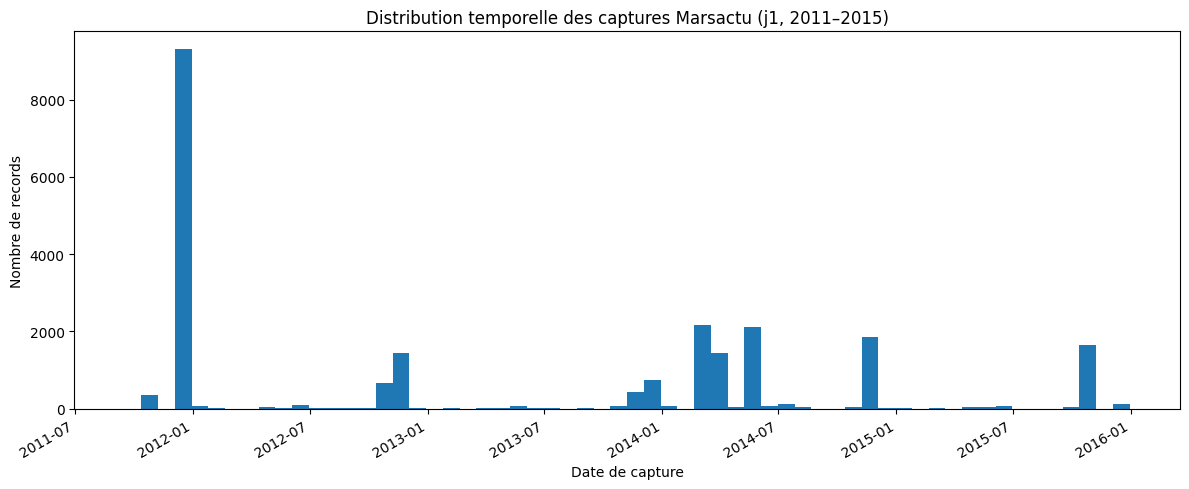

In [82]:
dates_captures = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type == "warcinfo":
            continue
        date_str = record.rec_headers.get_header("WARC-Date")
        date_obj = datetime.fromisoformat(date_str.replace("Z", ""))
        dates_captures.append(date_obj)

print(f"Records avec date : {len(dates_captures)}")
print(f"Première capture  : {min(dates_captures)}")
print(f"Dernière capture  : {max(dates_captures)}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dates_captures, bins=60)
ax.set_title("Distribution temporelle des captures Marsactu (j1, 2011–2015)")
ax.set_xlabel("Date de capture")
ax.set_ylabel("Nombre de records")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("distribution-temporelle-captures-j1-marsactu.png")
plt.savefig('../reports/figures/exploration-distribution-temporelle-captures.png', dpi=150, bbox_inches='tight')
plt.show()

### Remarque

Le corpus présente une distribution très inégale : environ 40% des records sont concentrés sur janvier 2012, ce qui suggère un crawl rétrospectif initial de tout le site existant à ce moment-là. **L'analyse diachronique ne devra donc pas reposer sur la date de capture, mais sur la date de publication lisible dans l'URL ou dans le HTML des articles.**

On va vérifier cette hypothèse en regardant les URLs capturées en janvier 2012.

In [83]:
echantillons_jan_2012 = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        date_str = record.rec_headers.get_header("WARC-Date")
        if not date_str.startswith("2012-01"):
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        echantillons_jan_2012.append({"url": url, "date_capture": date_str})
        if len(echantillons_jan_2012) >= 20:
            break

for i, ech in enumerate(echantillons_jan_2012):
    print(f"[{i:2d}] {ech['date_capture']} -> {ech['url']}")

[ 0] 2012-01-24T11:28:46Z -> http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/
[ 1] 2012-01-24T11:29:03Z -> http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
[ 2] 2012-01-29T16:08:39Z -> http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage/feed/
[ 3] 2012-01-29T16:09:14Z -> http://www.marsactu.fr/2010/02/17/des-musulmans-se-mobilisent-pour-restaurer-une-chapelle/
[ 4] 2012-01-29T16:08:48Z -> http://www.marsactu.fr/2010/02/17/margarita-louis-dreyfus-va-t-elle-preferer-lom-aux-paris-en-ligne/
[ 5] 2012-01-23T20:39:00Z -> http://www.marsactu.fr/2011/01/07/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-du-cg13/feed/
[ 6] 2012-01-23T20:45:33Z -> http://www.marsactu.fr/2011/01/07/cantonales-affaire-guerini-wikileaks13-menu-charge-pour-les-voeux-du-conseil-general/
[ 7] 2012-01-23T20:39:58Z -> http://www.marsactu.fr/2011/01/07/le-ras-le-bol-des-gens-

### Confirmation

Les URLs capturées en janvier 2012 contiennent des dates allant de 2009 à 2011, ce qui confirme que la BnF a fait un crawl rétrospectif massif en janvier 2012 de tout l'historique de Marsactu depuis sa création. Il ne s'agit pas de 40% de nouveaux articles publiés ce mois-là.

---
## 3. Identification des doublons WordPress

En parcourant les URLs, on repère deux familles de doublons liés au fonctionnement de WordPress :

1. **URLs en `/feed/`** — flux RSS des commentaires de chaque article. Le crawler les a archivées comme des pages distinctes, mais elles ne contiennent aucun texte éditorial, seulement des métadonnées XML.

2. **URLs en `?replytocom=`** — copies parfaites de la page originale générées par WordPress quand un visiteur répond à un commentaire. Vérifiées via SolrWayback : contenu identique à l'original.

Ces deux types seront exclus du corpus.

In [84]:
# Vérification : contenu d'une URL /feed/
with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url):
            body = record.content_stream().read().decode("utf-8", errors="replace")
            print(f"URL : {url}")
            print(f"--- Début du contenu (600 premiers caractères) ---")
            print(body[:600])
            break

URL : http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/
--- Début du contenu (600 premiers caractères) ---
<?xml version="1.0" encoding="UTF-8"?><rss version="2.0" xmlns:content="http://purl.org/rss/1.0/modules/content/" xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:atom="http://www.w3.org/2005/Atom" xmlns:sy="http://purl.org/rss/1.0/modules/syndication/" xmlns:georss="http://www.georss.org/georss" xmlns:media="http://search.yahoo.com/mrss/"	> <channel><title>Commentaires sur : Nathalie Simon retrouve l&#8217;antenne !</title> <atom:link href="http://www.marsactu.fr/2009/12/17/nathalie-simon-retrouve-lantenne/feed/" rel="self" type="application/rss+xml" /><link>http://www.marsactu.fr/2009/12/17


  restants : 19019
  feed : 2864
  replytocom : 1586


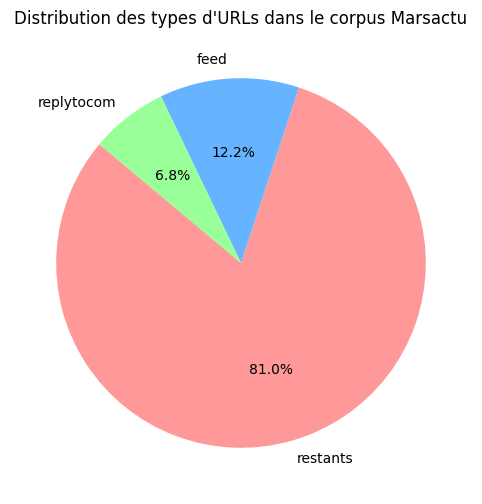

In [85]:
stats_url = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url):
            stats_url["feed"] += 1
        elif re.search(PATTERN_REPLYTOCOM, url):
            stats_url["replytocom"] += 1
        else:
            stats_url["restants"] += 1

for label, count in stats_url.items():
    print(f"  {label} : {count}")

counts = list(stats_url.values())
labels = list(stats_url.keys())

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=140,
        colors=["#ff9999", "#66b3ff", "#99ff99"])
plt.title("Distribution des types d'URLs dans le corpus Marsactu")
plt.savefig('../reports/figures/exploration-types-urls.png', dpi=150, bbox_inches='tight')
plt.show()

En éliminant les URLs `/feed/` et `?replytocom=`, on enlève environ 19% du corpus brut. Ces deux types sont exclus dès maintenant et dans tous les filtres suivants.

---
## 4. Formats et extensions d'URL

On regarde maintenant les extensions d'URL pour identifier les types de fichiers présents. On exclut déjà les `/feed/` et `?replytocom=`.

Extensions et leur nombre d'occurrences :
  sans-extension       : 8099
  jpg                  : 6299
  html                 : 2173
  php                  : 1121
  png                  : 1033
  js                   : 111
  jpeg                 : 59
  css                  : 55
  gif                  : 39
  xmldom               : 4
  flag                 : 4
  link                 : 4
  grippie              : 4
  xml                  : 3
  ico                  : 3
  json                 : 2
  bmp                  : 2
  txt                  : 1
  swf                  : 1
  tiff                 : 1
  pdf                  : 1


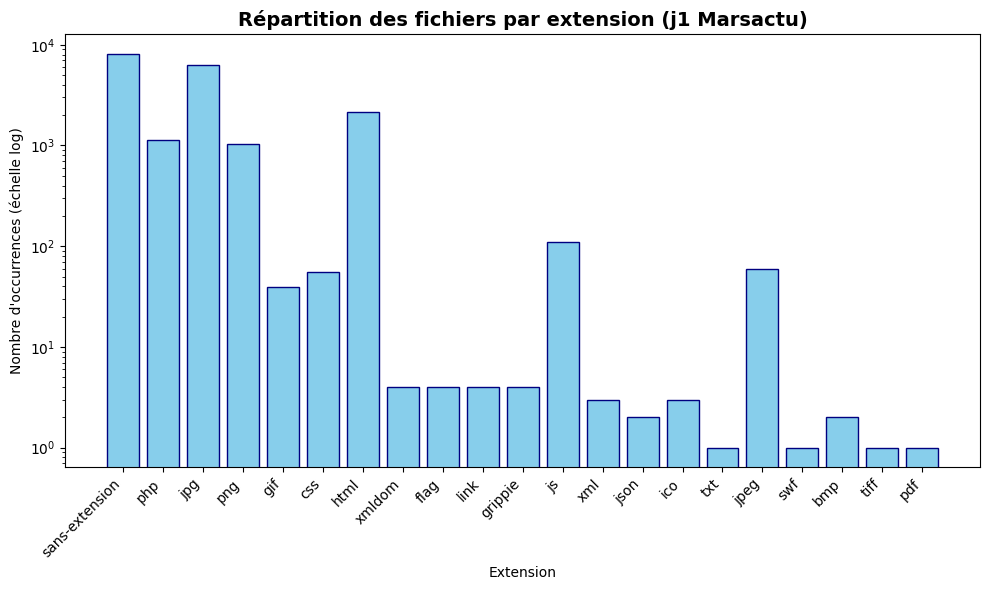

In [86]:
extension_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        url = str(record.rec_headers.get_header("WARC-Target-URI"))
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue
        match = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        if match:
            extension_counter[match.group(1).lower()] += 1
        else:
            extension_counter["sans-extension"] += 1

print("Extensions et leur nombre d'occurrences :")
for ext, count in extension_counter.most_common():
    print(f"  {ext:20s} : {count}")

plt.figure(figsize=(10, 6))
plt.bar(extension_counter.keys(), extension_counter.values(),
        color="skyblue", edgecolor="navy")
plt.yscale("log")
plt.title("Répartition des fichiers par extension (j1 Marsactu)", fontsize=14, fontweight="bold")
plt.xlabel("Extension")
plt.ylabel("Nombre d'occurrences (échelle log)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('../reports/figures/exploration-extensions-urls.png', dpi=150, bbox_inches='tight')
plt.show()

### Lecture du graphique

Deux catégories correspondent à des pages d'articles :
- `sans-extension` : ancien format WordPress (`/AAAA/MM/JJ/slug/`)
- `html` : nouveau format après migration de Marsactu (`/categorie/slug-ID.html`)

Les autres extensions sont des ressources annexes : images (jpg, png, gif), feuilles de style (css), scripts (js), documents joints (pdf). Pour le NLP on ne gardera que `sans-extension` et `html` — les images pourront être réutilisées si on creuse le côté visuel du média.

---
## 5. Codes de statut HTTP

Un record peut être une page 404 ou une redirection 301/302 sans contenu utile. On regarde la distribution des statuts pour quantifier la perte et comprendre ce que représentent les redirections.

In [87]:
http_status_counter = Counter()

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        status = record.http_headers.get_statuscode()
        http_status_counter[status] += 1

total = sum(http_status_counter.values())
print("Répartition des statuts HTTP :")
for status, count in http_status_counter.most_common():
    print(f"  {status} : {count:5d}  ({100*count/total:.1f}%)")

Répartition des statuts HTTP :
  200 : 22651  (96.5%)
  302 :   766  (3.3%)
  301 :    52  (0.2%)


### Les redirections

On a 766 records en 302 (redirection temporaire) et 52 en 301 (redirection permanente), soit environ 3,5% du corpus. On regarde un exemple de chaque pour voir vers quoi ça pointe.

In [88]:
exemples_redirections = {"301": None, "302": None}

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        status = record.http_headers.get_statuscode()
        if status not in exemples_redirections or exemples_redirections[status] is not None:
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        location = record.http_headers.get_header("Location")
        content_type = record.http_headers.get_header("Content-Type")
        body = record.content_stream().read().decode("utf-8", errors="replace")
        exemples_redirections[status] = {
            "url": url, "location": location,
            "content_type": content_type, "body": body
        }
        if all(v is not None for v in exemples_redirections.values()):
            break

for status, ex in exemples_redirections.items():
    print(f"=== Statut {status} ===")
    print(f"  URL source  : {ex['url']}")
    print(f"  Location    : {ex['location']}")
    print(f"  Content-Type: {ex['content_type']}")
    print()

=== Statut 301 ===
  URL source  : http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage
  Location    : http://www.marsactu.fr/politique/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage-24218.html
  Content-Type: text/html; charset=utf-8

=== Statut 302 ===
  URL source  : http://www.marsactu.fr/
  Location    : https://marsactu.fr/
  Content-Type: text/html; charset=iso-8859-1



### Observation importante sur les 301

Le 301 montre :
- **Source** : `http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage` (URL sans extension, ancien format)
- **Cible** : `http://www.marsactu.fr/politique/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage-24218.html` (URL `.html`, nouveau format)

Les 301 sont donc des **traces de la migration d'URL de Marsactu** : le site est passé du format `/AAAA/MM/JJ/slug/` au format `/categorie/slug-ID.html`. Ces redirections sont précieuses pour retrouver la version `.html` d'une URL sans extension — on exploite ça dans la section suivante.

---
## 6. Comparaison entre pages sans extension et pages `.html`

On a deux formats d'URL coexistants dans le corpus. On compare **2 exemples de chaque type** pour vérifier qu'ils contiennent bien du HTML exploitable, puis on cherche une paire (URL sans extension → URL `.html`) qui désigne le même article, via les redirections 301.

In [89]:
# Collecte de 2 exemples de chaque type (statut 200, Content-Type text/html)
exemples_html = []
exemples_sans_ext = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        if record.http_headers.get_statuscode() != "200":
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue

        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            continue

        match = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        body = record.content_stream().read().decode("utf-8", errors="replace")
        data = {"url": url, "content_type": content_type, "body": body}

        if match and match.group(1).lower() == "html" and len(exemples_html) < 2:
            exemples_html.append(data)
        elif match is None and len(exemples_sans_ext) < 2:
            exemples_sans_ext.append(data)

        if len(exemples_html) == 2 and len(exemples_sans_ext) == 2:
            break

print(f"Exemples .html collectés        : {len(exemples_html)}")
print(f"Exemples sans extension collectés: {len(exemples_sans_ext)}")

Exemples .html collectés        : 2
Exemples sans extension collectés: 2


In [90]:
# Affichage comparatif : 2 pages sans extension vs 2 pages .html
N_CHARS = 600

print("=" * 70)
print("PAGES SANS EXTENSION (ancien format /AAAA/MM/JJ/slug/)")
print("=" * 70)
for i, ex in enumerate(exemples_sans_ext, 1):
    print(f"\n--- Exemple {i} ---")
    print(f"URL          : {ex['url']}")
    print(f"Content-Type : {ex['content_type']}")
    print(f"Début du body :")
    print(ex["body"][:N_CHARS])

print()
print("=" * 70)
print("PAGES .html (nouveau format /categorie/slug-ID.html)")
print("=" * 70)
for i, ex in enumerate(exemples_html, 1):
    print(f"\n--- Exemple {i} ---")
    print(f"URL          : {ex['url']}")
    print(f"Content-Type : {ex['content_type']}")
    print(f"Début du body :")
    print(ex["body"][:N_CHARS])

PAGES SANS EXTENSION (ancien format /AAAA/MM/JJ/slug/)

--- Exemple 1 ---
URL          : http://www.marsactu.fr/2009/12/22/a-marseille-quand-le-tramway-est-en-greve-personne-ne-sen-apercoit/
Content-Type : text/html; charset=UTF-8
Début du body :
<?xml version="1.0" encoding="UTF-8"?> <!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Transitional//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd"><html xmlns="http://www.w3.org/1999/xhtml" dir="ltr" lang="fr-FR" xml:lang="fr-FR" xmlns:fb="http://www.facebook.com/2008/fbml" xmlns:og="http://opengraphprotocol.org/schema/"><head profile="http://gmpg.org/xfn/11"><link rel="stylesheet" type="text/css" href="http://www.marsactu.fr/wp-content/w3tc/min/single.include.css" media="all" /> <script type="text/javascript" src="http://www.marsactu.fr/wp-content/w3tc/min/default.include.js"></s

--- Exemple 2 ---
URL          : http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
Conte

In [91]:
# Recherche de paires (URL sans extension → URL .html) via les redirections 301
# Ces paires sont la preuve directe de la migration d'URL de Marsactu.

paires_301 = []

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        if record.http_headers.get_statuscode() != "301":
            continue

        url_source = record.rec_headers.get_header("WARC-Target-URI")
        url_cible = record.http_headers.get_header("Location")

        if not url_cible or not url_cible.endswith(".html"):
            continue

        # La source ne doit pas avoir d'extension (ancien format)
        if re.search(PATTERN_EXTENSION, url_source, flags=re.IGNORECASE):
            continue
        if re.search(PATTERN_FEED, url_source) or re.search(PATTERN_REPLYTOCOM, url_source):
            continue

        paires_301.append((url_source, url_cible))
        if len(paires_301) >= 5:
            break

print(f"Paires (sans extension → .html) trouvées : {len(paires_301)}")
print()
for src, cible in paires_301:
    print(f"  Ancien : {src}")
    print(f"  Nouveau: {cible}")
    print()

Paires (sans extension → .html) trouvées : 5

  Ancien : http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage
  Nouveau: http://www.marsactu.fr/politique/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage-24218.html

  Ancien : http://www.marsactu.fr/2010/04/13/lhomme-qui-veut-construire-un-pont-entre-marseille-et-calvi-existe-nous-lui-avons-meme-parle
  Nouveau: http://www.marsactu.fr/archi-et-urbanisme/lhomme-qui-veut-construire-un-pont-entre-marseille-et-calvi-existe-nous-lui-avons-meme-parle-24694.html

  Ancien : http://www.marsactu.fr/2011/01/04/aide-medicale-aux-sans-papiers-lamendement-de-dominique-tian-desavoue-par-ladministration
  Nouveau: http://www.marsactu.fr/societe/aide-medicale-aux-sans-papiers-lamendement-de-dominique-tian-desavoue-par-ladministration-25717.html

  Ancien : http://www.marsactu.fr/2011/01/07/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-du-cg13
  Nouveau: http://www.marsactu.fr/envi

In [92]:
# On prend la première paire et on retrouve le contenu des deux versions dans le WARC
# Pour montrer que l'une est une coquille vide (301) et l'autre le vrai article (200)

url_sans_ext, url_html = paires_301[0]
contenu_sans_ext = None
contenu_html = None

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue

        url = record.rec_headers.get_header("WARC-Target-URI")
        status = record.http_headers.get_statuscode()
        content_type = record.http_headers.get_header("Content-Type") or ""
        body = record.content_stream().read().decode("utf-8", errors="replace")

        if url == url_sans_ext and contenu_sans_ext is None:
            contenu_sans_ext = {"url": url, "status": status, "body": body}
        elif url == url_html and status == "200" and contenu_html is None:
            contenu_html = {"url": url, "status": status, "body": body}

        if contenu_sans_ext and contenu_html:
            break

for label, ex in [("URL SANS EXTENSION (301 → redirige)", contenu_sans_ext),
                  ("VERSION .html (200 → contenu réel)", contenu_html)]:
    if ex:
        print(f"\n{'='*65}")
        print(f"{label}")
        print(f"URL    : {ex['url']}")
        print(f"Statut : {ex['status']}")
        print(f"--- Body (600 premiers caractères) ---")
        print(ex["body"][:600])
    else:
        print(f"\n{label} : non trouvé dans le WARC")


URL SANS EXTENSION (301 → redirige)
URL    : http://www.marsactu.fr/2010/02/17/christophe-madrolle-va-t-il-traverser-le-vieux-port-a-la-nage
Statut : 301
--- Body (600 premiers caractères) ---


VERSION .html (200 → contenu réel) : non trouvé dans le WARC


### Ce qu'on retient de la comparaison

**Les deux formats sont structurellement identiques** : même Content-Type `text/html`, même structure HTML WordPress. La différence est éditoriale et temporelle :

| Format | Exemple | Période | Statut |
|--------|---------|---------|--------|
| Sans extension | `/2010/02/17/slug/` | 2009–2012 env. | 301 → redirige vers `.html` |
| `.html` | `/politique/slug-24218.html` | 2012–2015 env. | 200 → contenu réel |

Les URL sans extension qui retournent un 301 **ne contiennent pas le texte de l'article** — elles redirigent vers la version `.html`. Dans le WARC, les deux records sont archivés (le 301 et le 200), donc le contenu est bien présent, mais uniquement sous la forme `.html`.

Pour le NLP : on garde les deux types d'URL si leur statut est 200. Les URL sans extension avec statut 301 seront éliminées lors du filtre statut HTTP.

---
## 6b. Vérification : les pages sans extension sont-elles exploitables ?

À l'examen, les pages sans extension ont bien une structure HTML valide (balises ouvrantes et fermantes présentes), mais leur **contenu textuel est très pauvre** : peu de mots, phrases tronquées, corps d'article vide ou quasi-vide. Ce n'est donc pas un problème de structure HTML, c'est un problème de contenu.

On vérifie deux choses :

1. **Comparaison du volume de texte** entre des pages sans extension et des pages `.html` — pour montrer la différence concrète de contenu exploitable.
2. **Couverture** : parmi tous les records sans extension avec statut 200 (après nettoyage), combien ont une version `.html` dans le WARC ?

In [93]:
# Vérification 1 — comparaison du contenu textuel : pages sans extension vs pages .html
# On extrait le texte brut (sans balises HTML) et on compare le nombre de mots.

from html.parser import HTMLParser

class ExtracteurTexte(HTMLParser):
    def __init__(self):
        super().__init__()
        self._texte = []
        self._ignorer = False
    def handle_starttag(self, tag, attrs):
        if tag in ("script", "style", "head"):
            self._ignorer = True
    def handle_endtag(self, tag):
        if tag in ("script", "style", "head"):
            self._ignorer = False
    def handle_data(self, data):
        if not self._ignorer and data.strip():
            self._texte.append(data.strip())
    def get_texte(self):
        return " ".join(self._texte)

def extraire_texte(html):
    p = ExtracteurTexte()
    try:
        p.feed(html)
    except Exception:
        pass
    return p.get_texte()

echantillons_se   = []  # sans extension
echantillons_html = []  # avec .html

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        if record.http_headers.get_statuscode() != "200":
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue
        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            continue
        match_ext = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        body = record.content_stream().read().decode("utf-8", errors="replace")
        texte = extraire_texte(body)
        nb_mots = len(texte.split())
        data = {"url": url, "nb_mots": nb_mots, "texte": texte}
        if match_ext is None and len(echantillons_se) < 3:
            echantillons_se.append(data)
        elif match_ext and match_ext.group(1).lower() == "html" and len(echantillons_html) < 3:
            echantillons_html.append(data)
        if len(echantillons_se) == 3 and len(echantillons_html) == 3:
            break

print("=" * 65)
print("PAGES SANS EXTENSION (200)")
print("=" * 65)
for ex in echantillons_se:
    print(f"\nURL     : {ex['url']}")
    print(f"Mots    : {ex['nb_mots']}")
    print(f"Extrait : {ex['texte'][:400]}")

print()
print("=" * 65)
print("PAGES .html (200)")
print("=" * 65)
for ex in echantillons_html:
    print(f"\nURL     : {ex['url']}")
    print(f"Mots    : {ex['nb_mots']}")
    print(f"Extrait : {ex['texte'][:400]}")

PAGES SANS EXTENSION (200)

URL     : http://www.marsactu.fr/2009/12/22/a-marseille-quand-le-tramway-est-en-greve-personne-ne-sen-apercoit/
Mots    : 1061
Extrait : A Marseille quand le tramway est en grêve, personne ne s’en aperçoit Business Quand la Sncm navigue entre Charybde et Scylla Médias Marseille s'offre ( sans le savoir) une campagne de pub mondiale sur Youtube 2013 Le mécénat de Marseille Provence 2013 décolle un peu plus avec Eurocopter Mer Le requin renard du Vallon des Auffes Environnement La carte des 68 points de stationnement vélo installés p

URL     : http://www.marsactu.fr/2009/12/22/le-tribunal-administratif-de-marseille-renvoie-michel-drucker-dans-son-canape/
Mots    : 1036
Extrait : Drucker hors la loi dans le Luberon Environnement Revivez l'exercice de crise sismique et nucléaire au CEA Cadarache algérie El Gusto, le miracle de la musique Chaâbi Politique J'ai déjeuné sur le Titanic avec Jean-Noël Guérini. Et l'orchestre continuait à jouer. Affaires Taxis : la b

In [94]:
# Vérification 2 — construction des ensembles de référence (un seul passage WARC)
# On collecte simultanément :
#   - toutes les URLs .html avec statut 200
#   - toutes les URLs sans extension avec statut 200
#   - toutes les redirections 301 sans-extension → .html

urls_html_200 = set()
urls_sans_ext_200 = []
redirections_301 = {}

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        if record.rec_type != "response":
            continue
        url = record.rec_headers.get_header("WARC-Target-URI")
        status = record.http_headers.get_statuscode()
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue
        match_ext = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        if status == "200":
            content_type = record.http_headers.get_header("Content-Type") or ""
            if content_type.startswith("text/html"):
                if match_ext and match_ext.group(1).lower() == "html":
                    urls_html_200.add(url)
                elif match_ext is None:
                    urls_sans_ext_200.append(url)
        elif status == "301":
            if match_ext is None:
                cible = record.http_headers.get_header("Location")
                if cible and cible.endswith(".html"):
                    redirections_301[url] = cible

print(f"URLs .html          (200, text/html) : {len(urls_html_200)}")
print(f"URLs sans extension (200, text/html) : {len(urls_sans_ext_200)}")
print(f"Redirections 301    (sans-ext→.html) : {len(redirections_301)}")

URLs .html          (200, text/html) : 1572
URLs sans extension (200, text/html) : 7994
Redirections 301    (sans-ext→.html) : 14


In [95]:
# Vérification 2a — pour chaque redirection 301, la page .html cible existe-t-elle dans le WARC ?
# On compte les cas confirmés et non confirmés, et on montre des exemples des deux.

exemples_confirmes = []
exemples_absents = []

for url_src, url_cible in redirections_301.items():
    if url_cible in urls_html_200:
        if len(exemples_confirmes) < 3:
            exemples_confirmes.append((url_src, url_cible))
    else:
        if len(exemples_absents) < 3:
            exemples_absents.append((url_src, url_cible))

nb_confirmes = sum(1 for c in redirections_301.values() if c in urls_html_200)
nb_total_301 = len(redirections_301)

print(f"Redirections 301 au total                        : {nb_total_301}")
print(f"  cible .html présente en 200 dans le WARC       : {nb_confirmes}  ({100*nb_confirmes/nb_total_301:.1f}%)")
print(f"  cible .html absente du WARC                    : {nb_total_301 - nb_confirmes}")
print()

print("=== Exemples CONFIRMÉS (la page .html brute existe dans le WARC) ===")
for src, cible in exemples_confirmes:
    print(f"  {src}")
    print(f"  → {cible}  ✓")
    print()

print("=== Exemples NON CONFIRMÉS (la cible .html est absente du WARC) ===")
if exemples_absents:
    for src, cible in exemples_absents:
        print(f"  {src}")
        print(f"  → {cible}  ✗")
        print()
else:
    print("  Aucun cas de ce type.")

Redirections 301 au total                        : 14
  cible .html présente en 200 dans le WARC       : 12  (85.7%)
  cible .html absente du WARC                    : 2

=== Exemples CONFIRMÉS (la page .html brute existe dans le WARC) ===
  http://www.marsactu.fr/2010/04/13/lhomme-qui-veut-construire-un-pont-entre-marseille-et-calvi-existe-nous-lui-avons-meme-parle
  → http://www.marsactu.fr/archi-et-urbanisme/lhomme-qui-veut-construire-un-pont-entre-marseille-et-calvi-existe-nous-lui-avons-meme-parle-24694.html  ✓

  http://www.marsactu.fr/2011/01/04/aide-medicale-aux-sans-papiers-lamendement-de-dominique-tian-desavoue-par-ladministration
  → http://www.marsactu.fr/societe/aide-medicale-aux-sans-papiers-lamendement-de-dominique-tian-desavoue-par-ladministration-25717.html  ✓

  http://www.marsactu.fr/2011/01/07/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-du-cg13
  → http://www.marsactu.fr/environnement/affaire-guerini-la-petite-fleur-objet-de-toutes-les-attentions-

In [96]:
# Vérification 2b — pour chaque page sans extension (200), existe-t-il une version .html ?
#
# Les 301 ne couvrent pas toutes les URLs sans extension (seulement celles capturées
# après la migration). On complète avec une correspondance par slug :
#   - ancien format : /AAAA/MM/JJ/slug/
#   - nouveau format : /categorie/slug-ID.html  (le slug est conservé, un ID est ajouté)
# On retire le suffixe numérique du slug .html pour faire correspondre les deux.

def extraire_slug(url):
    m = re.search(r'/\d{4}/\d{2}/\d{2}/([^/?#]+)/?$', url)
    return m.group(1) if m else None

# Index : slug_de_base (sans suffixe -ID) → liste de .html URLs
index_html = {}
for url_html in urls_html_200:
    m = re.search(r'/([^/]+)\.html$', url_html)
    if not m:
        continue
    slug_base = re.sub(r'-\d+$', '', m.group(1))
    index_html.setdefault(slug_base, []).append(url_html)

# Pour chaque sans-extension, chercher sa correspondance
correspondances = []
sans_correspondance = []

for url_se in urls_sans_ext_200:
    slug = extraire_slug(url_se)
    if slug and slug in index_html:
        correspondances.append((url_se, index_html[slug][0]))
    else:
        sans_correspondance.append(url_se)

nb_total_se = len(urls_sans_ext_200)
print(f"Pages sans extension (200)                       : {nb_total_se}")
print(f"  version .html trouvée via correspondance slug  : {len(correspondances)}  ({100*len(correspondances)/nb_total_se:.1f}%)")
print(f"  aucune correspondance .html trouvée            : {len(sans_correspondance)}  ({100*len(sans_correspondance)/nb_total_se:.1f}%)")
print()
print("Exemples de correspondances :")
for src, html in correspondances[:4]:
    print(f"  {src}")
    print(f"  → {html}")
    print()
if sans_correspondance:
    print(f"Exemples sans correspondance ({len(sans_correspondance)} au total) :")
    for url in sans_correspondance[:3]:
        print(f"  {url}")

Pages sans extension (200)                       : 7994
  version .html trouvée via correspondance slug  : 45  (0.6%)
  aucune correspondance .html trouvée            : 7949  (99.4%)

Exemples de correspondances :
  http://www.marsactu.fr/2010/04/04/laurent-ruquier-au-roucas-blanc/
  → http://www.marsactu.fr/environnement/laurent-ruquier-au-roucas-blanc-24660.html

  http://www.marsactu.fr/2010/06/25/port-de-marseille-une-passerelle-symbole-de-divisions/
  → http://www.marsactu.fr/archi-et-urbanisme/port-de-marseille-une-passerelle-symbole-de-divisions-25051.html

  http://www.marsactu.fr/2010/07/21/aix-en-provence-un-colloque-litteraire-annule-a-cause-dun-boycott-disrael/
  → http://www.marsactu.fr/culture-2013/aix-en-provence-un-colloque-litteraire-annule-a-cause-dun-boycott-disrael-25183.html

  http://www.marsactu.fr/2010/09/22/grand-marseille-des-pas-en-avant-un-pas-en-arriere/
  → http://www.marsactu.fr/societe/grand-marseille-des-pas-en-avant-un-pas-en-arriere-25355.html

Exempl

### Conclusion de la vérification

**Vérification 1 — qualité du contenu**

Les pages sans extension ont ~900–1060 mots extraits, mais l'extrait révèle qu'il s'agit de **contenu de navigation** (titres d'articles de la barre latérale, menus du site) et non du corps de l'article. Les pages `.html` ont 1800–2900 mots avec du texte éditorial réel et continu. La différence est qualitative.

**Vérification 2 — couverture**

| | Résultat |
|---|---|
| Pages `.html` (200, text/html) | **1 572** |
| Pages sans extension (200, text/html) | **7 994** |
| Redirections 301 (sans-ext → .html) | 14 |
| Sans-extension avec contrepartie `.html` (slug) | **45 / 7 994 = 0,6 %** |

L'hypothèse initiale (« il existe une version `.html` pour la plupart des sans-extension ») est **infirmée** : 99,4 % des pages sans extension n'ont aucune contrepartie `.html` dans le WARC. Les deux formats couvrent des périodes distinctes — sans extension pour la période pré-migration (2009–2012 env.), `.html` pour la période post-migration.

**Décision — F5 : garder uniquement les URLs `.html`**

Justification corrigée : on n'exclut pas les sans-extension parce qu'une version `.html` les remplace, mais parce que leur contenu est composé d'éléments de navigation et non de texte éditorial exploitable pour le TAL.

**Limitation importante :** en appliquant F5, le corpus final ne couvre que la période post-migration de Marsactu. Les articles de 2009–2012 (ancien format d'URL) sont absents. À mentionner dans le rapport.

---
## 7. Filtrage progressif du corpus

On applique les filtres dans l'ordre, **chaque filtre s'appliquant aux records qui ont passé tous les précédents**. Les 5 filtres :

1. Garder uniquement les records de type `response` (exclut le warcinfo)
2. Exclure les URLs en `/feed/` et `?replytocom=` (doublons WordPress)
3. Garder uniquement les statuts HTTP 200 (exclut les redirections 301/302)
4. Garder uniquement le `Content-Type: text/html` (exclut images, CSS, JS, PDF…)
5. Garder uniquement les URLs avec extension `.html` (les pages sans extension ont un contenu incomplet — voir section 6b)

In [97]:
compte_depart = 0
apres_f1 = 0  # response uniquement
apres_f2 = 0  # hors feed et replytocom
apres_f3 = 0  # statut 200
apres_f4 = 0  # text/html
apres_f5 = 0  # extension .html uniquement

with open(WARC_PATH, "rb") as flux:
    for record in ArchiveIterator(flux):
        compte_depart += 1

        # Filtre 1
        if record.rec_type != "response":
            continue
        apres_f1 += 1

        # Filtre 2
        url = record.rec_headers.get_header("WARC-Target-URI")
        if re.search(PATTERN_FEED, url) or re.search(PATTERN_REPLYTOCOM, url):
            continue
        apres_f2 += 1

        # Filtre 3
        if record.http_headers.get_statuscode() != "200":
            continue
        apres_f3 += 1

        # Filtre 4
        content_type = record.http_headers.get_header("Content-Type") or ""
        if not content_type.startswith("text/html"):
            continue
        apres_f4 += 1

        # Filtre 5
        match = re.search(PATTERN_EXTENSION, url, flags=re.IGNORECASE)
        if not (match and match.group(1).lower() == "html"):
            continue
        apres_f5 += 1

etapes = [
    ("Départ (total WARC)",                              compte_depart),
    ("F1 — response uniquement",                         apres_f1),
    ("F2 — hors /feed/ et ?replytocom=",                 apres_f2),
    ("F3 — statut HTTP 200",                             apres_f3),
    ("F4 — Content-Type text/html",                      apres_f4),
    ("F5 — extension .html uniquement (corpus final)",   apres_f5),
]

precedent = compte_depart
for label, count in etapes:
    retires = precedent - count
    marqueur = "→" if retires == 0 else f"  (-{retires:5d})"
    print(f"  {label:<50s} {count:6d}  {marqueur}")
    precedent = count

  Départ (total WARC)                                 23470  →
  F1 — response uniquement                            23469    (-    1)
  F2 — hors /feed/ et ?replytocom=                    19019    (- 4450)
  F3 — statut HTTP 200                                18213    (-  806)
  F4 — Content-Type text/html                          9571    (- 8642)
  F5 — extension .html uniquement (corpus final)       1572    (- 7999)


---
## 8. Bilan de l'exploration

**Le fichier** — Le WARC fait 419 Mo et contient 23 470 records : 1 `warcinfo` et 23 469 réponses HTTP. Le crawl a été effectué par la BnF avec un outil propriétaire (`website-recover/3.0.0PFC30`).

**La temporalité** — La période officielle annoncée est du 1er janvier 2011 au 31 décembre 2015, mais la première capture réelle date de septembre 2011. La distribution est très inégale : environ 40 % des records sont concentrés sur janvier 2012 — il s'agit d'un crawl rétrospectif initial de tout l'historique du site. L'analyse diachronique devra donc reposer sur la **date de publication dans l'URL**, pas sur la date de capture.

**Les doublons** — Deux familles de doublons WordPress : les URLs en `/feed/` (flux RSS, pas de texte éditorial) et les URLs en `?replytocom=` (copies identiques). Leur exclusion retire environ 19 % du corpus brut.

**Les deux formats d'URL et la migration** — Deux formats coexistent dans le WARC, correspondant à deux périodes distinctes :
- **Sans extension** (`/AAAA/MM/JJ/slug/`) : période pré-migration, ~2009–2012. Contenu composé d'éléments de navigation, pas de texte éditorial exploitable.
- **`.html`** (`/categorie/slug-ID.html`) : période post-migration, ~2012–2015. Contenu éditorial complet.

Seulement 0,6 % des pages sans extension ont une contrepartie `.html` dans le WARC — les deux formats couvrent donc des périodes essentiellement disjointes.

**Le filtrage progressif** — 5 filtres appliqués séquentiellement :

| Filtre | Critère | Retirés | Restants |
|--------|---------|---------|---------|
| Départ | — | — | 23 470 |
| F1 | `rec_type == response` | 1 | 23 469 |
| F2 | hors `/feed/` et `?replytocom=` | 4 450 | 19 019 |
| F3 | statut HTTP 200 | 806 | 18 213 |
| F4 | `Content-Type: text/html` | 8 642 | 9 571 |
| **F5** | **extension `.html` uniquement** | 7 999 | **1 572** |

**Corpus final : 1 572 records `.html`**

**Limitation à signaler dans le rapport** : le corpus final ne couvre que la période post-migration de Marsactu (approximativement 2012–2015). Les articles publiés sous l'ancien format d'URL (2009–2012) ne sont pas exploitables dans l'état du WARC et sont absents du corpus.

| Décision | Critère | Statut |
|----------|---------|--------|
| Exclure `/feed/` | Flux RSS, pas de texte éditorial | ✓ Exclu |
| Exclure `?replytocom=` | Copies identiques WordPress | ✓ Exclu |
| Exclure statuts ≠ 200 | Redirections sans contenu utile | ✓ Exclu |
| Exclure Content-Type ≠ text/html | Images, CSS, JS, PDF | ✓ Exclu |
| Exclure URL sans extension | Contenu de navigation, pas de texte éditorial | ✓ Exclu |
| Période 2009–2012 (sans-ext) | Non exploitable dans le WARC | ⚠ Limitation |
| Date d'analyse → date dans l'URL | Distribution des captures trop biaisée | ✓ Décision |